# DI725 Assignment 1 — Sentiment Classification of Customer-Service Conversations

Didem Demir - 2739563

Github Repo : https://github.com/didemir/attention_sentiment_classification

WANDB : https://wandb.ai/didem-demir_01-middle-east-technical-university/DI725-sentiment/workspace?nw=nwuserdidemdemir_01

## Explatory Data Analysis (EDA)

### Initial Dataset Analysis

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

There is two csv files;
* test.csv
* train.csv

Test dataset contains 1153 line while train contains 34926 line.

In [2]:
PTH = "/content"
print("data files: ", os.listdir(PTH))

data files:  ['.config', 'test.csv', 'train.csv', 'sample_data']


In [11]:
def eda(pth: str) -> tuple:
  train_df = pd.read_csv(os.path.join(pth, "train.csv"))
  train_df.name = "Train"
  test_df = pd.read_csv(os.path.join(pth, "test.csv"))
  test_df.name = "Test"
  if train_df.columns.tolist() == test_df.columns.tolist():
    cols = train_df.columns.tolist()

    # ====== columns ======
    print(f" There are {len(cols)} identical columns acros both datasets:")
    for col in cols:
      print(f"\t {col}")

    # ====== missingness ======
    if test_df.isna().sum().any() or train_df.isna().sum().any():
      print("mising columns exist")
    else:
      print(f" No mising values in either datasets.")

    # ====== sample counts ======
    if len(train_df) == len(test_df):
      print(f" Both of the datasets have {len(train_df)} samples.")
    else:
      print(f" Train: {len(train_df)} samples  Test: {len(test_df)} samples")

    # ====== data types ======
    # TODO: do not print dtypes, instead check it and print something like, "all of them str".
    train_dtypes = train_df.dtypes.astype(str).tolist()
    test_dtypes = test_df.dtypes.astype(str).tolist()
    if train_dtypes == test_dtypes:
      if len(set(train_dtypes)) == 1:
        print(f" All columns are {train_dtypes[0]} type in both datasets.")
      else:
        print(f" Column types are identical across both datasets:")
        for col, dtype in zip(cols, train_dtypes):
          print(f"\t {col}: {dtype}")
    else:
      print(f"Column types do not match between datasets:")
      for col in cols:
        tr = str(train_df[col].dtype)
        te = str(test_df[col].dtype)
        if tr != te:
          print(f"\t {col}: Train={tr}, Test={te}")
    # ====== uniqueness ======
    print(f" Column Summaries:")
    for df in (train_df, test_df):
      print(f"{df.name} Dataset:")
      t = df.describe().T
      for i in t.index:
        print(f"     {i}: {t.loc[i, 'unique']} distinct values, {t.loc[i, 'count']} non-null rows")
      del t

  else:
    print("Columns of train dataset:")
    print(train_df.columns.tolist())
    print("Columns of test dataset:")
    print(test_df.columns.tolist())
  return train_df, test_df

train_df, test_df = eda(PTH)

 There are 11 identical columns acros both datasets:
	 issue_area
	 issue_category
	 issue_sub_category
	 issue_category_sub_category
	 customer_sentiment
	 product_category
	 product_sub_category
	 issue_complexity
	 agent_experience_level
	 agent_experience_level_desc
	 conversation
 No mising values in either datasets.
 Train: 970 samples  Test: 30 samples
 All columns are object type in both datasets.
 Column Summaries:
Train Dataset:
     issue_area: 6 distinct values, 970 non-null rows
     issue_category: 40 distinct values, 970 non-null rows
     issue_sub_category: 109 distinct values, 970 non-null rows
     issue_category_sub_category: 109 distinct values, 970 non-null rows
     customer_sentiment: 3 distinct values, 970 non-null rows
     product_category: 3 distinct values, 970 non-null rows
     product_sub_category: 50 distinct values, 970 non-null rows
     issue_complexity: 3 distinct values, 970 non-null rows
     agent_experience_level: 3 distinct values, 970 non-null

In [12]:
print(f"Number of samples available in Train set: {len(train_df)}")
print(f"Number of samples available in Test set : {len(test_df)}")

Number of samples available in Train set: 970
Number of samples available in Test set : 30


There are 11 variables (columns) in the dataset, which are represented in both the train and test sets. However, there is a volume mismatch: 30 samples will be used to test the model, while it will be trained and validated on 970 samples. This might cause some samples not to be represented in the test set, which must be kept in mind when commenting on test results.

970 samples for training are not enough to train an attention-based network from scratch. Therefore, it is decided to use a pre-trained model and fine-tune it for our case.

None of the variables in any of the columns has missing representations. However, there might be non-missing but not-representative samples that should be checked.

All of the columns are strings, so the upper-case and lower-case states and many other simple characteristics that may cause a string to look different from others should be eliminated. Simple actions are: stripping, casting all to lower (or upper).

Notes on `Column Summaries`:
* The train set seems to contain duplicated `conversation`. This should be checked.
* The `issue_area`, `customer_sentiment`, `product_category`, `issue_complexity`, `agent_experience_level`, and `agent_experience_level_desc` variables seem to be fully represented in the test dataset. However, this should be validated.
* The `issue_category` is represented with 40 distinct values in the train dataset. However, only 16 of the 40 values have been included in the test set.
* The `issue_sub_category` is represented with 109 distinct values in the train dataset. However, only 22 of the 109 values have been included in the test set.
* The `product_sub_category` is represented with 50 distinct values in the train dataset. However, only 21 of the 50 values have been included in the test set.

In [13]:
x, y, z = train_df[["issue_category", "issue_sub_category", "issue_category_sub_category"]].iloc[0].tolist()
print(f"issue_category:", x)
print(f"issue_sub_category:", y)
print(f"issue_category_sub_category:", z)
del x, y, z

issue_category: Mobile Number and Email Verification
issue_sub_category: Verification requirement for mobile number or email address during login
issue_category_sub_category: Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login


As shown above, `issue_category_sub_category` is the concatenation of `issue_category` and `issue_sub_category`; therefore, it does not provide additional information.

Because of that, I will drop this `issue_category_sub_category` column.

In [14]:
train_df[["agent_experience_level", "agent_experience_level_desc"]].value_counts()

,,count
agent_experience_level,agent_experience_level_desc,
junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.",490
experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.",339
inexperienced,"may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predefined steps or escalate to supervisors for support",141


As shown above, the `agent_experience_level_desc` is a description of `agent_experience_level`.
This is not needed for training and unnecessarily increases the dataset size.

Therefore, the descriptive `agent_experience_level_desc` column will be dropped.

In [15]:
# drop unnecessary columns
train_df.drop(["issue_category_sub_category", "agent_experience_level_desc"], axis=1, inplace=True)
print(f"Remaining Columns")
print(train_df.columns)

Remaining Columns
Index(['issue_area', 'issue_category', 'issue_sub_category',
       'customer_sentiment', 'product_category', 'product_sub_category',
       'issue_complexity', 'agent_experience_level', 'conversation'],
      dtype='object')


----
**The duplicated `conversation` issue:**

In [16]:
train_df[train_df["conversation"].duplicated() == True]

,issue_area,issue_category,issue_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,conversation
286,Order,Order Delivery Issues,Package shows as delivered but cannot be found,negative,Men/Women/Kids,T-Shirt,less,inexperienced,"Agent: You're welcome, Jane. Have a great day!"
750,Order,Order Delivery Issues,Order approved but not shipped,negative,Appliances,Sandwich Maker,less,experienced,"Agent: You're welcome, Jane. Have a great day!"


In [17]:
train_df[train_df["conversation"].duplicated() == True]["conversation"]

,conversation
286,"Agent: You're welcome, Jane. Have a great day!"
750,"Agent: You're welcome, Jane. Have a great day!"


The conversation seems not to capture the whole. Only the ending part is included. There might be other conversation samples that does not contain the full dialog.

---
**Validation of fully represented columns:**

In [18]:
def visualize_dist(df: pd.DataFrame, title:str = '') -> None:
    """
    Visualizes a str column's distinct variables.
    Args:
        df (pd.DataFrame): The dataframe that contains data
        title (str)      : The Title of the figure. Default is ''.
    """
    sorted_df = df.value_counts().sort_index()
    # TODO: Check and verify that the df has only one column
    # TODO: Check if it causes a problem when df has multiple columns
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
    fig.suptitle(title, fontweight="bold", fontsize=15)
    ax1.barh(sorted_df.index, sorted_df.values)
    ax2.pie(sorted_df.values, autopct="%1.1f%%", startangle=90)
    ax2.axis("equal")
    ax2.legend(loc="upper right", labels=sorted_df.index)
    plt.tight_layout()
    plt.show()

* **customer_sentiment**

This will be our target. So, its distribution will be essential for our further decisions.

In [19]:
train_df.customer_sentiment.value_counts()

,count
customer_sentiment,
neutral,542
negative,411
positive,17


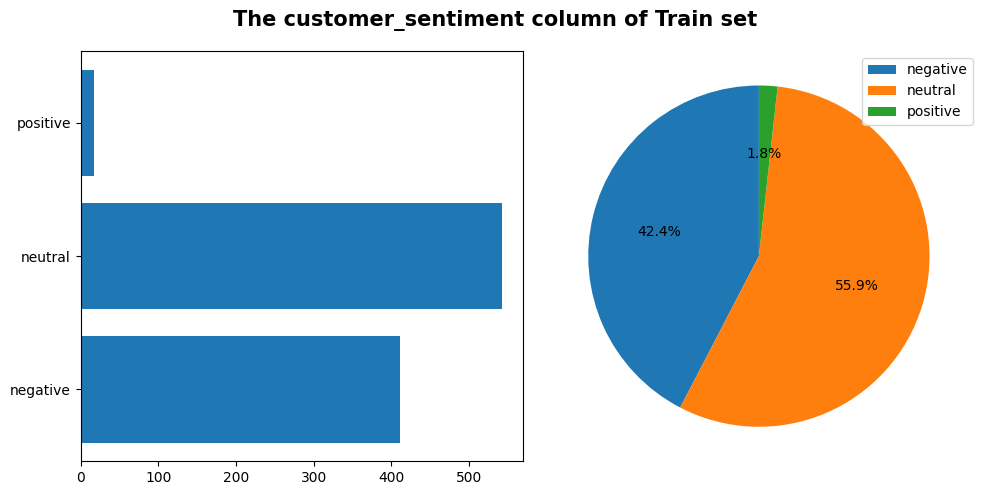

In [20]:
col = "customer_sentiment"
visualize_dist(df = train_df[col], title = f"The {col} column of Train set")

As shown above, our target variable, customer_sentiment, has extremely imbalanced samples. In particular, the number of positive samples is so low that the model may overfit and not even predict `positive`.

Because of that, we will use the **F1 score** as our primary metric, as it treats all classes equally, so that not predicting `positive` is not penalized.

An additional step to address this problem would be to compute class weights so that the model learns to place greater weight on the positive class.

Even after all these steps, there will be only 17 positive samples for model to learn. Therefore, oversampling of positive samples might be beneficial. Without this, the model barely sees positive samples. While oversampling, we can apply "synonym replacement" or paraphrasing to prevent overfitting and further improve the diversity.

Due to this imbalance in the dataset, to help the model learn `positive` truly, it is important that we give the model the other features to learn.

---

**Correlation:**

We are dealing with purely categorical variables.
The correlation of each variable with customer sentiment can be assessed using Cramer's V.

                        Cramers_V
issue_sub_category       1.000000
issue_category           0.738909
issue_area               0.295057
product_sub_category     0.213278
agent_experience_level   0.069088
product_category         0.059665
issue_complexity         0.041245


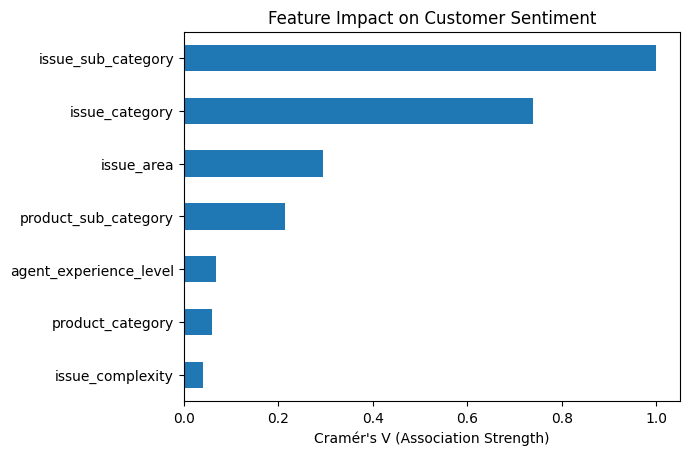

In [21]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x: pd.Series, y: pd.Series) -> np.float64:
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


cols = train_df.columns
results = {}
for col in cols:
    if col == "conversation":
        continue
    if col != "customer_sentiment":
        results[col] = cramers_v(train_df[col], train_df["customer_sentiment"])

corr_df = pd.DataFrame.from_dict(results, orient='index', columns=['Cramers_V'])
corr_df = corr_df.sort_values(by='Cramers_V', ascending=False)

print(corr_df)
corr_df.plot(kind='barh', legend=False)
plt.xlabel("Cramér's V (Association Strength)")
plt.title("Feature Impact on Customer Sentiment")
plt.gca().invert_yaxis()
plt.show()




Cramer's V measures the association between other features and our target, customer_sentiment.
From the result above, we can comment that;
* `issue_sub_category` is perfectly associated with `customer_sentiment` with score of 1. Some subcategories might be directly related to sentiments. Whatever the cause is, keeping this column in the training dataset would have the same effect as having two sentiment columns. Therefore, it should be removed.
* `issue_category` is highly associated with the `customer_sentiment` with score of ~0,8. It shows that this issue category information provides strong insight into the customer's sentiment. Therefore, it will be used to further enhance the model's learning.
* The `issue_area` and `product_sub_category` scored ~0,3. The variables might be useful for the model; they can be used.
* The `agent_experience_level`, `product_category`, and `issue_complexity` have scores that below 0,1. It seems that they do not have much impact on customers' sentiment. Therefore, to prevent noise in the training data, we will drop these.

In [22]:
max_token = 0
min_token = float("inf")
unique_conv = train_df["conversation"].unique().tolist()
for conv in unique_conv:
    if len(conv) > max_token:
        max_token = len(conv)
    if len(conv) < min_token:
        min_token = len(conv)

print(f"The largest conversation has {max_token} characters.")
print(f"The shortest conversation has {min_token} characters.")


The largest conversation has 5708 characters.
The shortest conversation has 46 characters.


5708 characters are approximately 1000 tokens. The maximum token length BERT can take is 512. Since the beginning of the conversation would include an explanation of the problem, greetings, etc., the ending might provide more information about sentiment. Therefore, the conversations with more than 512 tokens will be truncated from the beginning.

#### Conclusion

Because the number of training samples is low (970), training an attention-based network from scratch is impractical. Instead, we can fine-tune a pre-trained BERT-like model. For simplicity, I will use the original BERT.

Cramer's V measure showed that some categorical features are strongly associated with our target, which could benefit our classification model.

Therefore, the proposed architecture will use our BERT-like model to extract features from raw text. Then, we will concatenate these features with our tabular data and feed them into another model, such as a simple MLP, to complete the classification. This type of architecture is called **Multimodal Architecture**.

_What kind of model will be used to classify? Explain here when decided._

Due to class imbalance in the target distribution, additional decisions are made:
* We will be using the F1 score as the primary metric due to its equal treatment of all classes.
* We will be computing weights for classes to force the model to care for the low-volume samples.
* Since only 1% of the training data is labelled as `positive`, it will be oversampled.
* Methods such as synonym replacement and paraphrasing will be utilized to increase the diversity of oversampled `positive` samples.



In [23]:
train_df.drop(["issue_sub_category",
               "agent_experience_level",
               "product_category",
               "issue_complexity"], axis=1, inplace=True)

## Data Pre-Process

### Oversampling and Data Augmentation of Positive Class

#### Oversampling positive samples

The easiest oversampling method would be to simply repeat positive samples until the classes are more balanced.
However, the number of positive samples is so small that this method would lead to excessive repetition, causing the model to overfit.

Another method is to sample from the positive class more frequently during training, instead of blindly duplicating data.
This method prevents duplication in the dataset, therefore reducing overfitting.
However, this won't be a solution to our diversity problem.

As a result, I decided to apply oversampling with data augmentation.
My method is to generate variations from 17 positive samples.
This approach addresses the diversity issue while managing the low sample count.
The techniques will be:
* **Synonym replacement:**
    * A combination of `nltk` and `wordnet` will be used.
    * The "Agent" and "Customer" words are not going to be replaced.
    * A problem with this method is that WordNet provides context-free synonyms, whereas BERT's architecture is explicitly designed to process contextual relationships.
* **Back translation:**
    * _not sure about that_
* **Paraphrasing:**
    * Gemini or OpenAI api can be used.

To prevent these techniques from destroying changes from another, each will be applied individually, not sequentially.

##### Paraphrasing

In [ ]:
positive_conversations = train_df[train_df.customer_sentiment == "positive"].conversation.tolist()

In [ ]:
from dotenv import load_dotenv
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
from google import genai
from google.genai import types
client = genai.Client(api_key=GEMINI_API_KEY)

In [ ]:
from tqdm import tqdm


In [ ]:
def paraphrase_conv(client: genai.client.Client, text: str) -> str:
    prompt = (
        "Paraphrase the following customer support conversation. Keep the meaning and sentiment exactly the same. "
        "Do not change speaker roles (Agent/Customer).\n\n"
        "CRITICAL INSTRUCTION: Output ONLY the raw paraphrased text. Do not include introductory phrases, explanations, or conversational filler like 'Here is the paraphrase:'.\n\n"
        f"{text}"
    )
    response = client.models.generate_content(
        model = "gemma-3-27b-it",
        contents=prompt
    )
    return response.text.strip()

def augment_with_paraphrase(df: pd.DataFrame, client: genai.client.Client = client) -> pd.DataFrame:
    length = len(df)
    df_copy = df.copy()
    for i in tqdm(range(length)):
        curr_row = df_copy.loc[i]
        res = paraphrase_conv(client, curr_row.conversation)
        curr_row.conversation = res
        df_copy.loc[length+i] = curr_row
    return df_copy

In [ ]:
max_ch, max_word = 0, 0
for conv in positive_conversations:
    if len(conv) > max_ch:
        max_ch = len(conv)
    if len(conv.split(" ")) > max_word:
        max_word = len(conv.split(" "))
print("Maximum character count:", max_ch)
print("Maximum word count:", max_word)

Maximum character count: 2190
Maximum word count: 360


In [ ]:
positive_df = train_df[train_df.customer_sentiment == "positive"].reset_index(drop=True)
aug_pos_df = augment_with_paraphrase(positive_df)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [02:09<00:00,  7.60s/it]


In [ ]:
aug_pos_df

,issue_area,issue_category,customer_sentiment,product_sub_category,conversation
0,Order,Placing an Order,positive,Toy,Agent: Thank you for calling BrownBox Customer...
1,Order,Order Confirmation and Status,positive,Sunglas,Agent: Thank you for calling BrownBox Customer...
2,Order,Product Information and Tags,positive,T-Shirt,"Agent: Hello, thank you for calling BrownBox c..."
3,Order,Product Information and Tags,positive,Sweatshirt,Agent: Thank you for calling BrownBox Customer...
4,Order,Placing an Order,positive,Washing Machine,"Customer: Hi, I'm interested in purchasing a w..."
5,Order,Product Information and Tags,positive,External Hard Disk,"Agent: Hello, thank you for contacting BrownBo..."
6,Order,Order Confirmation and Status,positive,Juicer/Mixer/Grinder,Agent: Thank you for calling BrownBox Customer...
7,Order,Order Confirmation and Status,positive,Electric Cooker,Agent: Thank you for calling BrownBox Customer...
8,Order,Order Confirmation and Status,positive,Wet Grinder,Agent: Thank you for calling BrownBox Customer...
9,Order,Order Confirmation and Status,positive,Kitchen Chimney,Agent: Thank you for calling BrownBox Customer...


##### Back translation

We will be translating the English conversations to another language (s) and then back to English.
This will naturally cause paraphrasing.


In [26]:
from transformers import MarianMTModel, MarianTokenizer

trans_tokenizer      = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
trans_model          = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
back_trans_tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-fr-en')
back_trans_model     = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-fr-en')

def back_translation(tokenizer, model, text: str) -> str:
    translated = model.generate(**tokenizer(text, return_tensors="pt", padding=True))
    dec_trans = tokenizer.decode(translated[0], skip_special_tokens=True)
    return dec_trans

def augment_with_backtrans(df: pd.DataFrame) -> pd.DataFrame:
    length = len(df)
    df_copy = df.copy()
    for i in tqdm(range(length)):
        curr_row = df_copy.loc[i]
        frres = back_translation(trans_tokenizer, trans_model, curr_row.conversation)
        res = back_translation(back_trans_tokenizer, back_trans_model, frres)
        curr_row.conversation = res
        df_copy.loc[length+i] = curr_row
    return df_copy

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [36]:
import torch
import nltk
from tqdm import tqdm
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

def back_translation(tokenizer, model, text: str) -> str:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    translated = model.generate(**inputs)
    return tokenizer.decode(translated[0], skip_special_tokens=True)


def back_translate_text(text: str) -> str:
    sentences = sent_tokenize(text)

    translated_sentences = []

    for sent in sentences:
        try:
            # EN -> FR
            fr = back_translation(trans_tokenizer, trans_model, sent)

            # FR -> EN
            en = back_translation(back_trans_tokenizer, back_trans_model, fr)

            translated_sentences.append(en)

        except Exception as e:
            translated_sentences.append(sent)

    return " ".join(translated_sentences)

def augment_with_backtrans(df: pd.DataFrame) -> pd.DataFrame:
    augmented_rows = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        new_row = row.copy()

        new_row["conversation"] = back_translate_text(row.conversation)

        augmented_rows.append(new_row)

    df_aug = pd.DataFrame(augmented_rows)

    return pd.concat([df, df_aug], ignore_index=True)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [37]:
backtrans_pos_def = augment_with_backtrans(aug_pos_df)

100%|██████████| 34/34 [08:26<00:00, 14.89s/it]


In [38]:
backtrans_pos_def

,issue_area,issue_category,customer_sentiment,product_sub_category,conversation
0,Order,Placing an Order,positive,Toy,Agent: Thank you for calling BrownBox Customer...
1,Order,Order Confirmation and Status,positive,Sunglas,Agent: Thank you for calling BrownBox Customer...
2,Order,Product Information and Tags,positive,T-Shirt,"Agent: Hello, thank you for calling BrownBox c..."
3,Order,Product Information and Tags,positive,Sweatshirt,Agent: Thank you for calling BrownBox Customer...
4,Order,Placing an Order,positive,Washing Machine,"Customer: Hi, I'm interested in purchasing a w..."
...,...,...,...,...,...
63,Order,Placing an Order,positive,T-Shirt,"Agent: Hello, thank you for contacting BrownBo..."
64,Order,Product Information and Tags,positive,Electric Kettle,"Agent: Hello, thank you for contacting BrownBo..."
65,Order,Order Confirmation and Status,positive,Wrist Watch,"Agent: Hello, thank you for contacting BrownBo..."
66,Order,Order Confirmation and Status,positive,Pram/Stroller,"Agent: Hello, thank you for contacting BrownBo..."


In [39]:
backtrans_pos_def.conversation.tolist()[-1]

"Client: Hello, I'm calling you to ask about the return policy of a kitchen fireplace I want to buy from BrownBox – I can't locate it on the website. Hello, I'm Sarah, and I'm happy to help. Can you tell me the name or product code of the Fireplace kitchen you're looking at? Client: This is the ABC kitchen fireplace, code KCH12345. Agent: Thank you. Let me extract the product information and the seller's return policy for you. Could you hold briefly? Client: Yes, thank you. Agent: Thank you for waiting. I found the details. The ABC Kitchen Chimney is sold by XYZ Appliances, one of our approved dealers. Their policy states that if the chimney arrives damaged or does not work properly, you can return it within 10 days for a replacement or a refund. If you just decide you don't want to, you have 7 days to return it, but there will be a 20% restocking fee. Client: All right, thank you. Could you also explain the product specifications for this stack? Of course. The ABC kitchen fireplace is

In [40]:
res = pd.concat([train_df[train_df.customer_sentiment != "positive"].reset_index(drop=True), backtrans_pos_def]).reset_index(drop=True)

In [41]:
res

,issue_area,issue_category,customer_sentiment,product_sub_category,conversation
0,Login and Account,Mobile Number and Email Verification,neutral,Oven Toaster Grills (OTG),Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,neutral,Computer Monitor,Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,neutral,Juicer/Mixer/Grinder,Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,neutral,Water Purifier,"Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,negative,Bp Monitor,Agent: Thank you for contacting BrownBox custo...
...,...,...,...,...,...
1016,Order,Placing an Order,positive,T-Shirt,"Agent: Hello, thank you for contacting BrownBo..."
1017,Order,Product Information and Tags,positive,Electric Kettle,"Agent: Hello, thank you for contacting BrownBo..."
1018,Order,Order Confirmation and Status,positive,Wrist Watch,"Agent: Hello, thank you for contacting BrownBo..."
1019,Order,Order Confirmation and Status,positive,Pram/Stroller,"Agent: Hello, thank you for contacting BrownBo..."


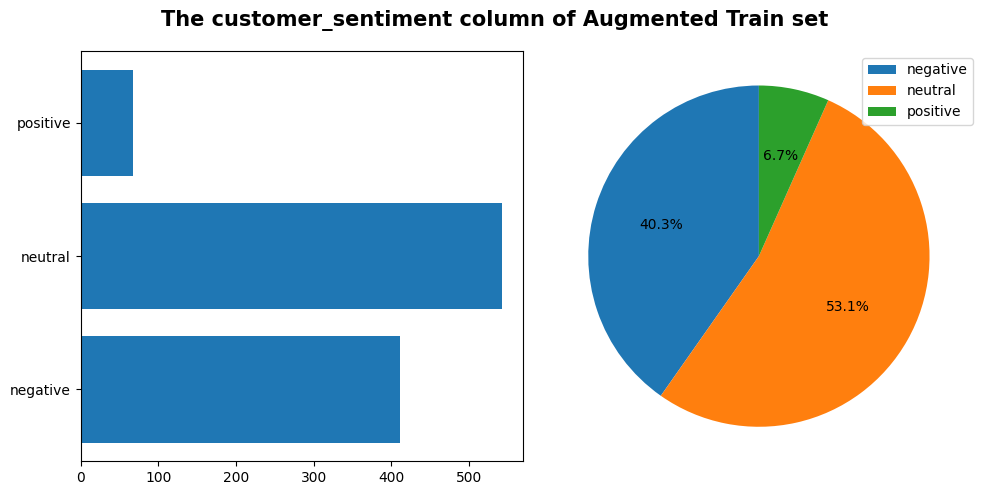

In [42]:
col = "customer_sentiment"
visualize_dist(df = res[col], title = f"The {col} column of Augmented Train set")

#### Find weights for sentiment classes

In [43]:
from sklearn.utils.class_weight import compute_class_weight

In [44]:
sentiment_classes = {
    "neutral":0,"negative":1,"positive":2
}
sentiments = res["customer_sentiment"].tolist()
sentiments = [sentiment_classes[i] for i in sentiments]
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.asarray([0,1,2]),
    y=sentiments
)
weights

array([0.62792128, 0.82806164, 5.00490196])

Later, we will be using these weights in our loss function to force the model to care about the positive classes.

### Preprocessing for BERT



In [45]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
def tokenize_keep_last(text, tokenizer, max_len=512):
    encoded = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        return_tensors=None
    )

    input_ids = encoded["input_ids"]

    if len(input_ids) > max_len - 2:
        input_ids = input_ids[-(max_len - 2):]
    input_ids = [tokenizer.cls_token_id] + input_ids + [tokenizer.sep_token_id]
    attention_mask = [1] * len(input_ids)
    pad_len = max_len - len(input_ids)

    input_ids = input_ids + [tokenizer.pad_token_id] * pad_len
    attention_mask = attention_mask + [0] * pad_len

    return {
        "input_ids": torch.tensor(input_ids),
        "attention_mask": torch.tensor(attention_mask)
    }

def prepare_bert_inputs(df):
    input_ids_list = []
    attention_masks_list = []

    for text in df["conversation"]:
        encoded = tokenize_keep_last(text, tokenizer, 512)

        input_ids_list.append(encoded["input_ids"])
        attention_masks_list.append(encoded["attention_mask"])

    return {
        "input_ids": torch.stack(input_ids_list),
        "attention_mask": torch.stack(attention_masks_list)
    }

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [46]:
bert_data = prepare_bert_inputs(res)
bert_data["input_ids"].shape

Token indices sequence length is longer than the specified maximum sequence length for this model (551 > 512). Running this sequence through the model will result in indexing errors


torch.Size([1021, 512])

In [47]:
res.columns

Index(['issue_area', 'issue_category', 'customer_sentiment',
       'product_sub_category', 'conversation'],
      dtype='object')

In [48]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "issue_area",
    "issue_category",
    "product_sub_category",
]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    res[col] = le.fit_transform(res[col])
    encoders[col] = le

tabular_data = torch.tensor(res[categorical_cols].values, dtype=torch.long)
tabular_data

tensor([[ 1, 19, 25],
        [ 0, 23,  7],
        [ 0, 31, 20],
        ...,
        [ 2, 21, 49],
        [ 2, 21, 28],
        [ 2, 28, 21]])

## Model (Training & Evaluation)

In [49]:
import torch.nn as nn
from transformers import BertModel

class BertTabularModel(nn.Module):
    def __init__(self, num_classes, cat_dims, emb_dim=8, dropout=0.3, freeze_bert=False):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        self.embeddings = nn.ModuleList([
            nn.Embedding(n, emb_dim) for n in cat_dims
        ])
        self.classifier = nn.Sequential(
            nn.Linear(768 + emb_dim * len(cat_dims), 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, tabular_data):
        cls_output = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        tabular_emb = torch.cat([emb(tabular_data[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        return self.classifier(torch.cat([cls_output, tabular_emb], dim=1))


cat_dims = [res[col].nunique() for col in categorical_cols]

model = BertTabularModel(num_classes=3, cat_dims=cat_dims, emb_dim=8, dropout=0.3, freeze_bert=False)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_tail(text, max_len=512):
    ids = tokenizer(str(text), add_special_tokens=False, return_tensors=None)["input_ids"]
    ids = ids[-(max_len - 2):]  # keep tail — more sentiment signal than the opening
    ids  = [tokenizer.cls_token_id] + ids + [tokenizer.sep_token_id]
    mask = [1] * len(ids)
    pad  = max_len - len(ids)
    return {
        "input_ids":      torch.tensor(ids  + [tokenizer.pad_token_id] * pad, dtype=torch.long),
        "attention_mask": torch.tensor(mask + [0] * pad,                       dtype=torch.long),
    }

class SentimentDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = tokenize_tail(row["conversation"])
        return {
            "input_ids":      enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "tabular":        torch.tensor([row[c] for c in categorical_cols], dtype=torch.long),
            "label":          torch.tensor(row["label"], dtype=torch.long),
        }

label_map = {"neutral": 0, "negative": 1, "positive": 2}
res["label"] = res["customer_sentiment"].map(label_map)
print(res["label"].value_counts())
train_df, val_df = train_test_split(res, test_size=0.15, stratify=res["label"], random_state=42)

train_loader = DataLoader(SentimentDataset(train_df), batch_size=16, shuffle=True)
val_loader   = DataLoader(SentimentDataset(val_df),   batch_size=16, shuffle=False)
print(f"Train: {len(train_df)}  Val: {len(val_df)}")

label
0    542
1    411
2     68
Name: count, dtype: int64
Train: 867  Val: 154


In [53]:
from transformers import get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight("balanced", classes=np.array([0,1,2]), y=res["label"].values)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float).to(DEVICE))

optimizer = torch.optim.AdamW([
    {"params": model.bert.parameters(),       "lr": 2e-5},
    {"params": model.embeddings.parameters(), "lr": 1e-3},
    {"params": model.classifier.parameters(), "lr": 1e-3},
], weight_decay=0.01)

EPOCHS      = 6
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer,
                  num_warmup_steps=int(0.1 * total_steps),
                  num_training_steps=total_steps)

In [54]:
from sklearn.metrics import f1_score, accuracy_score
import wandb

wandb.init(project="DI725-sentiment", name="bert-tabular-v1")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0, [], []
    with (torch.enable_grad() if train else torch.no_grad()):
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            tab  = batch["tabular"].to(DEVICE)
            lbl  = batch["label"].to(DEVICE)
            logits = model(ids, mask, tab)
            loss   = criterion(logits, lbl)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item()
            preds.extend(logits.argmax(-1).cpu().numpy())
            labels.extend(lbl.cpu().numpy())
    return total_loss/len(loader), f1_score(labels, preds, average="macro", zero_division=0), accuracy_score(labels, preds)

best_f1, best_ckpt = 0, "best_model.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_f1, vl_acc = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.3f} train_f1={tr_f1:.3f}  val_loss={vl_loss:.3f} val_f1={vl_f1:.3f}")
    wandb.log({"train/loss": tr_loss, "train/f1": tr_f1, "val/loss": vl_loss, "val/f1": vl_f1, "epoch": epoch})
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        torch.save(model.state_dict(), best_ckpt)
        print(f"  ✓ Best model saved (val_f1={vl_f1:.3f})")

wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: didem-demir_01 (didem-demir_01-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


Epoch 1/6  train_loss=1.018 train_f1=0.435  val_loss=0.597 val_f1=0.716
  ✓ Best model saved (val_f1=0.716)
Epoch 2/6  train_loss=0.501 train_f1=0.772  val_loss=0.400 val_f1=0.827
  ✓ Best model saved (val_f1=0.827)
Epoch 3/6  train_loss=0.264 train_f1=0.907  val_loss=0.487 val_f1=0.841
  ✓ Best model saved (val_f1=0.841)
Epoch 4/6  train_loss=0.142 train_f1=0.954  val_loss=0.797 val_f1=0.805
Epoch 5/6  train_loss=0.089 train_f1=0.969  val_loss=0.591 val_f1=0.862
  ✓ Best model saved (val_f1=0.862)
Epoch 6/6  train_loss=0.055 train_f1=0.988  val_loss=0.765 val_f1=0.831


epoch,▁▂▄▅▇█
train/f1,▁▅▇███
train/loss,█▄▃▂▁▁
val/f1,▁▆▇▅█▇
val/loss,▄▁▃█▄▇
epoch,6
train/f1,0.98826
train/loss,0.05502
val/f1,0.83138
val/loss,0.76546


Test Macro-F1: 0.6137
Test Accuracy: 0.6333

              precision    recall  f1-score   support

     neutral       0.50      0.90      0.64        10
    negative       0.78      0.70      0.74        10
    positive       1.00      0.30      0.46        10

    accuracy                           0.63        30
   macro avg       0.76      0.63      0.61        30
weighted avg       0.76      0.63      0.61        30



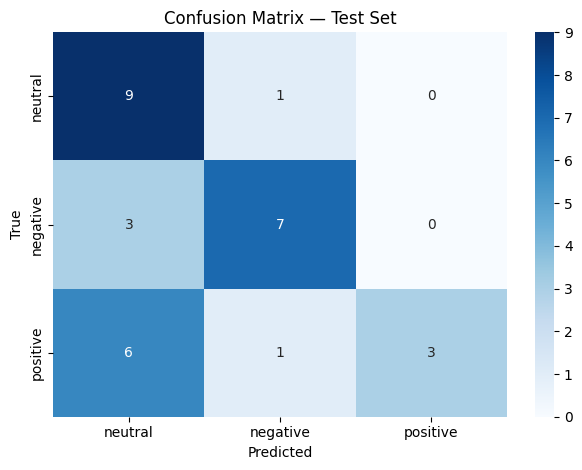

In [57]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load(best_ckpt))
test_df["label"] = test_df["customer_sentiment"].map(label_map)
for col in categorical_cols:
    test_df[col] = encoders[col].transform(test_df[col].astype(str))

test_loader = DataLoader(SentimentDataset(test_df), batch_size=16, shuffle=False)

_, preds, labels = 0, [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        logits = model(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE), batch["tabular"].to(DEVICE))
        preds.extend(logits.argmax(-1).cpu().numpy())
        labels.extend(batch["label"].numpy())

label_names = ["neutral", "negative", "positive"]
print(f"Test Macro-F1: {f1_score(labels, preds, average='macro', zero_division=0):.4f}")
print(f"Test Accuracy: {accuracy_score(labels, preds):.4f}\n")
print(classification_report(labels, preds, target_names=label_names, zero_division=0))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()